Steel demand

In [147]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.optimize import curve_fit
import pandas_datareader.wb as wb
import statsmodels.api as sm

Load data

In [199]:
# Load data

def load_files(filename):
    base_path = Path.cwd().parent
    historic_folder = base_path / "data" / "raw" / "Steel"
    
    file_path = historic_folder / filename
    df = pd.read_excel(file_path)
    
    return df

DRI_file = "DRI.xlsx"

DRI_data = load_files(DRI_file)
steel_data = load_files("steel_demand.xlsx")

base_path = Path.cwd().parent
future_GDP_path = base_path / "data" / "raw" / "future_GDP.csv"
future_GDP = pd.read_csv(future_GDP_path)

Look at data

In [120]:
# Look at the data
display(DRI_data)

display(steel_data)

,Year,HDRI [Mt],Total DRI [Mt],Unnamed: 3,https://www.midrex.com/wp-content/uploads/MidrexSTATSBook2023.Final_.pdf,Unnamed: 5,Unnamed: 6
0,1971,0.00,0.95,NaN,https://www.sms-group.com/de-de/insights/all-i...,NaN,NaN
1,1972,0.00,1.39,NaN,2024,NaN,117.0
2,1973,0.00,1.90,NaN,2050,NaN,500.0
3,1974,0.00,2.72,NaN,NaN,NaN,NaN
4,1975,0.00,2.81,NaN,NaN,NaN,NaN
5,1976,0.00,3.02,NaN,NaN,NaN,NaN
6,1977,0.00,3.52,NaN,NaN,NaN,NaN
7,1978,0.00,5.00,NaN,NaN,NaN,NaN
8,1979,0.00,6.64,NaN,NaN,NaN,NaN
9,1980,0.00,7.14,NaN,NaN,NaN,NaN


,Year,Population,Steel,Steel per capita (t),Steel per capita
0,1950,2471424.002,189.0,76.47413,107.586966
1,1951,2514761.693,NaN,NaN,108.039967
2,1952,2559092.377,NaN,NaN,108.518598
3,1953,2609080.302,NaN,NaN,109.024134
4,1954,2659132.169,NaN,NaN,109.557896
...,...,...,...,...,...
96,2046,9464147.498,NaN,NaN,259.992351
97,2047,9511631.710,NaN,NaN,260.549750
98,2048,9557460.245,NaN,NaN,261.077834
99,2049,9601611.841,NaN,NaN,261.577957


Clean data

In [177]:
# New dataframe with relevant columns
DRI_historic = DRI_data[["Year", "Total DRI [Mt]"]].copy()

# Add GDP data
# indicator code for GDP (current US$)
indicator = "NY.GDP.MKTP.CD"

start_year = DRI_historic["Year"].min()
end_year = DRI_historic["Year"].max()

# download
gdp_data = wb.download(
    indicator=indicator,
    country="WLD",            # WLD = world aggregate
    start=start_year,
    end=end_year
)

# rename for clarity
gdp_data = gdp_data.rename(columns={"NY.GDP.MKTP.CD": "GDP_current_USD"})
gdp_data = gdp_data.reset_index()

# Ensure both columns are integers
DRI_historic["Year"] = DRI_historic["Year"].astype(int)
gdp_data["year"] = gdp_data["year"].astype(int)

# Merge GDP into DRI_historic by matching years
DRI_historic = DRI_historic.merge(
    gdp_data[["year", "GDP_current_USD"]],
    left_on="Year",       # your steel/DRI dataframe column
    right_on="year",      # GDP dataframe column
    how="left"
)

DRI_historic = DRI_historic.drop(columns=["year"])

# Population data from 1971 to 2023
population = steel_data[(steel_data["Year"] >= 1971) & (steel_data["Year"] <= 2023)]["Population"].values

DRI_historic["Population"] = population

# Scale correctly
DRI_historic["GDP_scaled"] = DRI_historic["GDP_current_USD"] / 1e9 # scale to 100 billions?
DRI_historic["Population_scaled"] = DRI_historic["Population"] / 1e3 # scale to 100 millions?

display(DRI_historic)

c:\Users\ovid\AppData\Local\miniconda3\envs\masterthesis\Lib\site-packages\pandas_datareader\wb.py:592: UserWarning: Non-standard ISO country codes: WLD
  warnings.warn(
C:\Users\ovid\AppData\Local\Temp\ipykernel_29616\387476718.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gdp_data = wb.download(


,Year,Total DRI [Mt],GDP_current_USD,Population,GDP_scaled,Population_scaled
0,1971,0.95,3.319897e+12,3732670.026,3319.897075,3732.670026
1,1972,1.39,3.834214e+12,3807025.705,3834.213544,3807.025705
2,1973,1.90,4.688558e+12,3882809.654,4688.557692,3882.809654
3,1974,2.72,5.419514e+12,3958800.430,5419.514194,3958.800430
4,1975,2.81,6.035142e+12,4034031.762,6035.142145,4034.031762
5,1976,3.02,6.560174e+12,4107438.793,6560.173647,4107.438793
6,1977,3.52,7.416443e+12,4181053.962,7416.442857,4181.053962
7,1978,5.00,8.779662e+12,4254673.630,8779.661745,4254.673630
8,1979,6.64,1.015546e+13,4329521.373,10155.462903,4329.521373
9,1980,7.14,1.145277e+13,4407557.683,11452.768542,4407.557683


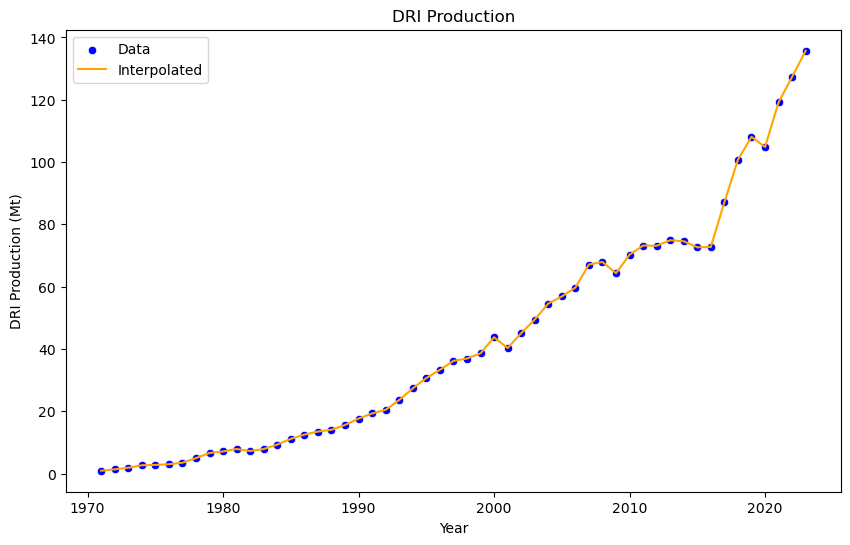

In [179]:
# Find minimum and maximum steel production
DRI_min = DRI_historic["Total DRI [Mt]"].min()
DRI_max = DRI_historic["Total DRI [Mt]"].max()

# Estimate steel inflow for missing years using linear interpolation
DRI_historic["DRI Interpolated"] = DRI_historic["Total DRI [Mt]"].interpolate(method='linear')

# Define x and y for curve fitting
x_data = DRI_historic["Year"].values
y_data = DRI_historic["DRI Interpolated"].values

# Plot the data
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_data, y=y_data, label="Data", color="blue")
sns.lineplot(x=x_data, y=y_data, label="Interpolated", color="orange")
plt.title("DRI Production")
plt.xlabel("Year")
plt.ylabel("DRI Production (Mt)")
plt.legend()
plt.show()

GDP elasticity beta: 1.3373093592250922


C:\Users\ovid\AppData\Local\Temp\ipykernel_29616\2755816365.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


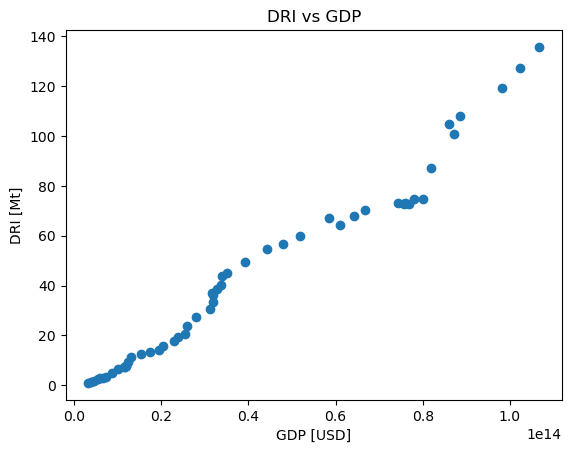

In [300]:
# Take logs
y = np.log(DRI_historic["Total DRI [Mt]"])
X = np.log(DRI_historic["GDP_current_USD"])

# Add constant
X = sm.add_constant(X)

# Fit regression
model = sm.OLS(y, X).fit()

beta = model.params[1]
print("GDP elasticity beta:", beta)

# DRI vs GDP
plt.scatter(DRI_historic["GDP_current_USD"], DRI_historic["Total DRI [Mt]"])
plt.xlabel("GDP [USD]")
plt.ylabel("DRI [Mt]")
plt.title("DRI vs GDP")
plt.show()

In [195]:
DRI_historic["DRI_growth"] = DRI_historic["Total DRI [Mt]"].pct_change()
DRI_historic["GDP_growth"] = DRI_historic["GDP_current_USD"].pct_change()
DRI_historic["POP_growth"] = DRI_historic["Population"].pct_change()

# Drop first NaN row
df_growth = DRI_historic.dropna()

print("Correlation DRI-GDP growth:",
      df_growth["DRI_growth"].corr(df_growth["GDP_growth"]))

print("Correlation DRI-POP growth:",
      df_growth["DRI_growth"].corr(df_growth["POP_growth"]))

Correlation DRI-GDP growth: 0.6624494396417325
Correlation DRI-POP growth: 0.44815982673049376


In [194]:
DRI_historic["GDP_lag1"] = DRI_historic["GDP_current_USD"].shift(1)
lag_corr = DRI_historic["Total DRI [Mt]"].corr(DRI_historic["GDP_lag1"])
print(f"Correlation DRI vs GDP lag 1 year: {lag_corr:.2f}")

Correlation DRI vs GDP lag 1 year: 0.98


Steel per capita regression

In [180]:
# Define logistic regression function
def logistic(x:np.ndarray,ti:float,tau:float,C0:float,C1:float) -> np.ndarray:
    return (C1 - C0)/(1 + np.exp(-(x - ti) / tau)) + C0  

In [181]:
# Define x and y for curve fitting
x_data = DRI_historic["Year"].values
y_data = DRI_historic["DRI Interpolated"].values

Polynomial regression

Logistic fit parameters: ti=2022.9999999999086, tau=13.368834566885521, C0=4.406385807607362e-15, C1=247.66389347192958


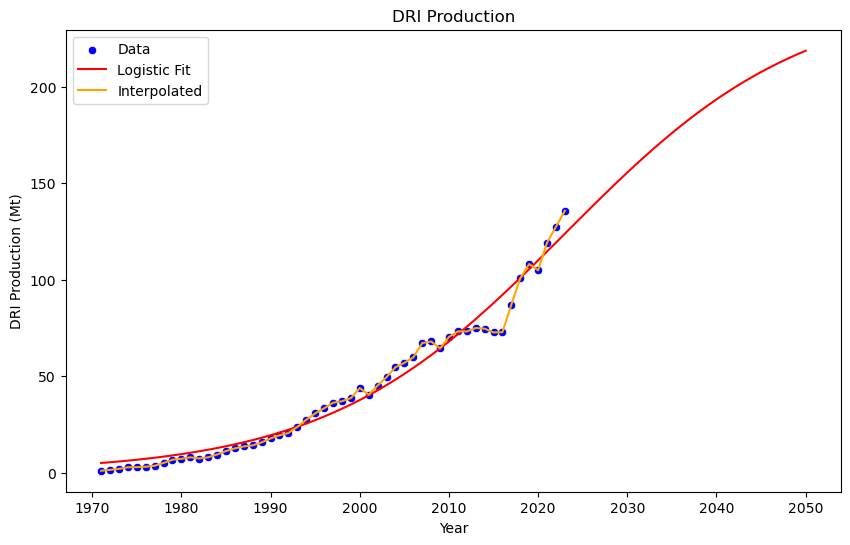

In [182]:
# Fit the logistic function to the data to interpolate and extrapolate data
popt, pcov = curve_fit(
    logistic,
    x_data,
    y_data,
    bounds=([min(x_data), 0, 0, 0], [max(x_data), 10**6, 10**5, 10**6]),
    maxfev=1000000
)

# Extract fitted parameters
ti_fit, tau_fit, C0_fit, C1_fit = popt

# Predict values using the fitted parameters
extended_years = np.arange(1971, 2051)
pred_outputs = logistic(extended_years, *popt)

print(f"Logistic fit parameters: ti={ti_fit}, tau={tau_fit}, C0={C0_fit}, C1={C1_fit}")

# Plot the data and the fit
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_data, y=y_data, label="Data", color="blue")
sns.lineplot(x=extended_years, y=pred_outputs, label="Logistic Fit", color="red")
sns.lineplot(x=x_data, y=DRI_historic["DRI Interpolated"], label="Interpolated", color="orange")
plt.title("DRI Production")
plt.xlabel("Year")
plt.ylabel("DRI Production (Mt)")
plt.legend()
plt.show()

In [272]:
# Future dataframe
GDP_future = future_GDP[
    (future_GDP["region"] == "World") &
    (future_GDP["variable"] == "GDP|PPP") &
    (future_GDP["unit"] == "billion USD_2017/yr") &
    (future_GDP["scenario"].isin(["SSP1", "SSP2", "SSP3", "SSP5"]))
]

# Keep relevant columns and rename
GDP_future = GDP_future[["scenario"] + [col for col in GDP_future.columns if col.startswith("20")]]

# Only columns with years 2025, 2030, 2035, 2040, 2045, 2050
GDP_future = GDP_future[["scenario", "2025", "2030", "2035", "2040", "2045", "2050"]]


GDP_long = GDP_future.melt(
    id_vars="scenario",
    var_name="Year",
    value_name="GDP"
)

GDP_future = GDP_long.pivot(
    index="Year",
    columns="scenario",
    values="GDP"
).reset_index()


In [309]:
# Step 1: make sure 'Year' is numeric
GDP_future["Year"] = GDP_future["Year"].astype(int)

# Step 2: set Year as index
GDP_future = GDP_future.set_index("Year")

# Step 3: reindex to full yearly range
GDP_future = GDP_future.reindex(range(2025, 2051))

# Step 4: interpolate missing values
GDP_future = GDP_future.interpolate(method="linear")

# Step 5: reset index
GDP_future = GDP_future.reset_index()

DRI_future = GDP_future.copy()
DRI_future["DRI_baseline"] = pred_outputs[extended_years >= 2025]


scenario,Year,SSP1,SSP2,SSP3,SSP5,DRI_baseline
0,2025,151744.093879,151744.194959,151742.644209,151745.888489,133.077443
1,2026,156823.320927,156752.603162,156669.861892,156923.372395,137.668034
2,2027,161902.547976,161761.011365,161597.079575,162100.856302,142.220435
3,2028,166981.775025,166769.419568,166524.297258,167278.340208,146.722573
4,2029,172061.002073,171777.827771,171451.514941,172455.824115,151.162915
5,2030,177140.229122,176786.235975,176378.732625,177633.308022,155.530584
6,2031,183007.144850,182006.108027,180836.384304,184472.091816,159.815454
7,2032,188874.060578,187225.980079,185294.035983,191310.875610,164.008232
8,2033,194740.976307,192445.852131,189751.687662,198149.659404,168.100524
9,2034,200607.892035,197665.724184,194209.339341,204988.443198,172.084880


In [313]:
# Define base year
base_year = 2025

# Compute multipliers relative to base year, scenario by scenario
for scen in ["SSP1", "SSP2", "SSP3", "SSP5"]:
    # Get GDP in base year for this scenario
    gdp_base = DRI_future.loc[DRI_future["Year"] == base_year, scen].values[0]
    
    # Compute multiplier column
    DRI_future[scen + "_mult"] = DRI_future[scen] / gdp_base

# Compute scenario DRI using GDP elasticity beta
for scen in ["SSP1", "SSP2", "SSP3", "SSP5"]:
    DRI_future["DRI_" + scen] = DRI_future["DRI_baseline"] * (DRI_future[scen + "_mult"] ** beta)

# Make df with only Year and DRI for each scenario
DRI_scenarios = DRI_future[["Year"] + ["DRI_" + scen for scen in ["SSP1", "SSP2", "SSP3", "SSP5"]]]

scenario,Year,DRI_SSP1,DRI_SSP2,DRI_SSP3,DRI_SSP5
0,2025,133.077443,133.077443,133.077443,133.077443
1,2026,143.864982,143.778103,143.678584,143.985462
2,2027,155.094505,154.913075,154.705278,155.346149
3,2028,166.752314,166.468632,166.143770,167.145843
4,2029,178.822887,178.429263,177.978562,179.369011
5,2030,191.289099,190.777891,190.192630,191.998464
6,2031,205.313377,203.812717,202.065677,207.510932
7,2032,219.781418,217.220351,214.230996,223.578152
8,2033,234.671625,230.980157,226.669134,240.177134
9,2034,249.961454,245.070825,239.360276,257.283513


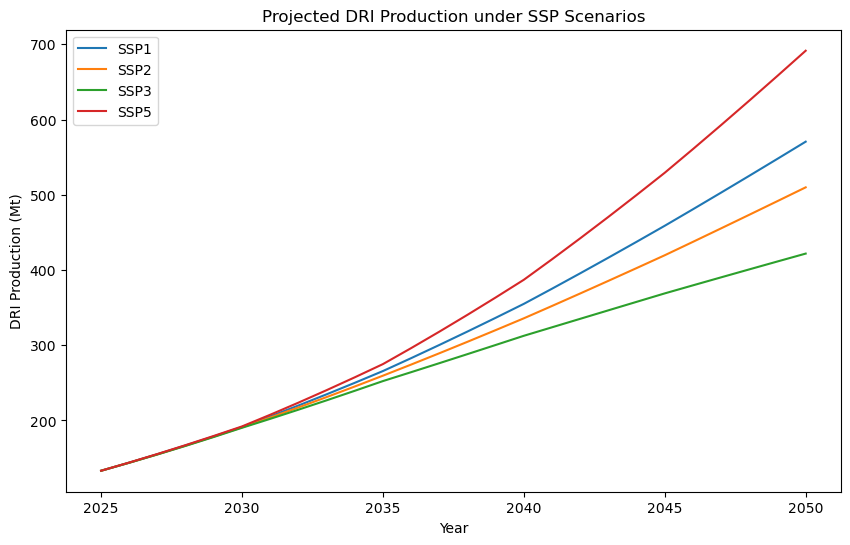

In [315]:
display(DRI_scenarios)

# PLot scenarios
plt.figure(figsize=(10, 6))
for scen in ["SSP1", "SSP2", "SSP3", "SSP5"]:
    plt.plot(DRI_future["Year"], DRI_future["DRI_" + scen], label=scen)
plt.title("Projected DRI Production under SSP Scenarios")
plt.xlabel("Year")
plt.ylabel("DRI Production (Mt)")
plt.legend()
plt.show()

In [320]:
# Adjust for production vs actual production capacity
production_capacity_factor = 0.8

# Copy scenario df
required_capacity = DRI_scenarios.copy()

# Drop Year column for capacity calculation
required_capacity = required_capacity.drop(columns=["Year"])
required_capacity = required_capacity / production_capacity_factor

# Add Year column back as first column
required_capacity.insert(0, "Year", DRI_scenarios["Year"])

Save data

In [333]:
# Create new dataframe with years 1971 to 2050 and columns for each scenario and one for historic DRI
DRI_scenarios_full = pd.DataFrame({
    "Year": np.arange(1971, 2051)
})

# Add historic DRI
DRI_scenarios_full = DRI_scenarios_full.merge(
    DRI_historic[["Year", "Total DRI [Mt]"]],
    on="Year",
    how="left"
)

# Add scenario DRI
for scen in ["SSP1", "SSP2", "SSP3", "SSP5"]:
    DRI_scenarios_full = DRI_scenarios_full.merge(
        required_capacity[["Year", "DRI_" + scen]],
        on="Year",
        how="left"
    )

# Fill in 140.8 for year 2024 in Total DRI [Mt] (midrex report)
DRI_scenarios_full.loc[DRI_scenarios_full["Year"] == 2024, "Total DRI [Mt]"] = 140.8

# Save data to csv in Path.cwd().parent / "data" / "processed"
output_path = Path.cwd().parent / "data" / "processed" / "DRI_scenarios.csv"
DRI_scenarios_full.to_csv(output_path, index=False)